
# Tutorial 3 — From a PDF to a structured synthesis procedure

This is the core of the toolbox, taken one stage at a time. You start with a
PDF and end with a `GeneralSynthesisOntology` object per material: precursors
with amounts, ordered steps with temperatures and durations, equipment.

Each stage is a swappable component behind a small interface, so the same
notebook shows you both *what* the pipeline does and *where* you would plug in
your own implementation.

```
PDF (bytes)
    |
[1. PDF extraction]      -> markdown text + figures embedded as base64
    |
[2. Figure extraction]   -> FigureInfo objects (segmented, classified)
    |
[3. Text cleaning]       -> text without figures and references
    |
[4. Material extraction] -> the list of materials actually synthesised
    |
[5. Synthesis extraction]-> GeneralSynthesisOntology per material
```

## What you'll learn

1. How to turn a PDF into markdown with either a local (Docling) or API-based
   (Mistral OCR) extractor
2. How figures are segmented and classified out of that markdown
3. Why the text is cleaned before it reaches the LLM
4. How DSPy signatures turn a prompt + a Pydantic schema into structured output
5. How to read numerical data back out of a plot with a vision model

## Prerequisites

- The package installed (`uv sync && uv pip install -e .`)
- A PDF to work on — **no sample papers ship with this repo** (`data/` is
  git-ignored). Tutorial 2 shows how to find one; any open-access materials
  paper will do.
- **Runtime:** 5–15 min per paper. **Cost:** a few cents of LLM calls with the
  default models; the figure step downloads a ~1 GB vision model on first run.


## Step 0 — API keys and your `.env` file

Nothing in this project takes an API key as a function argument. Keys live in a
single `.env` file at the repository root, get loaded into the process
environment once per session, and LiteLLM/DSPy read them from there. That means
**your keys never appear in notebook code, notebook outputs, or git history**.

### Create your `.env`

From the repository root:

```bash
cp .env.example .env
```

Then open `.env` and fill in the keys you need — one per line, no quotes and no
spaces around `=`:

```
GEMINI_API_KEY=AIza...
ANTHROPIC_API_KEY=sk-ant-...
```

`.env` is git-ignored, so it never gets committed.

### Keys used by this tutorial

| Key | What it unlocks | Needed here? |
|-----|-----------------|--------------|
| `GEMINI_API_KEY` | Material + synthesis extraction (the default models) | **yes** |
| `MISTRAL_API_KEY` | Mistral OCR for PDF -> markdown | only for Option A in Step 1 |
| `ANTHROPIC_API_KEY` | Reading data points off plots with Claude vision | only for the last section |

Where to get them: **Gemini** (free tier is enough for this tutorial) at
[aistudio.google.com](https://aistudio.google.com/app/apikey), **Anthropic** at
[console.anthropic.com](https://console.anthropic.com/), **Mistral** at
[console.mistral.ai](https://console.mistral.ai/), **OpenRouter** at
[openrouter.ai/keys](https://openrouter.ai/keys).

> Docling (Option B in Step 1) runs locally and needs **no** key at all, so
> `GEMINI_API_KEY` alone is enough to complete Steps 1–5.

The next cell loads `.env` and reports which keys arrived — it prints only the
key *length*, never the value, so the output is safe to share.

In [18]:
import os

from dotenv import find_dotenv, load_dotenv

# find_dotenv walks up from the working directory, so this works whether you
# started Jupyter at the repo root or inside this folder.
env_path = find_dotenv(usecwd=True)
load_dotenv(env_path, override=True)

REQUIRED_KEYS = {
    "GEMINI_API_KEY": "material + synthesis extraction",
}

OPTIONAL_KEYS = {
    "MISTRAL_API_KEY": "Mistral OCR (Step 1, Option A)",
    "ANTHROPIC_API_KEY": "plot data extraction (final section)",
}


def report_keys(required, optional):
    """Print which API keys .env provided, without revealing their values."""
    print(f".env loaded from: {env_path or 'NOT FOUND'}\n")
    missing = []
    for name, purpose in {**required, **optional}.items():
        value = os.getenv(name)
        is_required = name in required
        if value:
            status = f"set ({len(value)} chars)"
        elif is_required:
            status = "MISSING"
            missing.append(name)
        else:
            status = "not set"
        tag = "required" if is_required else "optional"
        print(f"  {name:<28} {status:<16} [{tag}] {purpose}")
    if missing:
        raise RuntimeError(
            "Missing required key(s): "
            + ", ".join(missing)
            + ". Copy .env.example to .env at the repository root and fill "
            "them in, then re-run this cell."
        )
    print("\nAll required keys are present.")


report_keys(REQUIRED_KEYS, OPTIONAL_KEYS)

.env loaded from: /Users/ribes/phd/lematerial-llm-synthesis/.env

  GEMINI_API_KEY               set (53 chars)   [required] material + synthesis extraction
  MISTRAL_API_KEY              set (32 chars)   [optional] Mistral OCR (Step 1, Option A)
  ANTHROPIC_API_KEY            set (108 chars)  [optional] plot data extraction (final section)

All required keys are present.


### How a key gets from `.env` to the model

You will not see an API key anywhere else in this notebook. The chain is:

1. `load_dotenv()` above put the values into `os.environ`.
2. `get_llm_from_name("gemini-3.0-flash")` looks the name up in `LLM_REGISTRY`
   (`src/llm_synthesis/utils/llms.py`), which maps the friendly alias to a real
   LiteLLM model string — and, for models routed through OpenRouter, names the
   environment variable that holds the key.
3. LiteLLM reads the provider's standard variable (`GEMINI_API_KEY`,
   `ANTHROPIC_API_KEY`, `OPENAI_API_KEY`, `MISTRAL_API_KEY`) from the
   environment at call time.

So switching models is a one-line change, and adding a provider means adding an
entry to `LLM_REGISTRY` plus a line in `.env` — never editing call sites.

---
## Setup and Imports

In [2]:
import base64
import io
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from PIL import Image as PILImage

# .env was already loaded in Step 0 - keys are in os.environ from here on.

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

### Configuration

Set your paper details and data directory here:

In [3]:
# Configure your paper details. No sample PDFs ship with this repo
# (`data/` is gitignored), so point DATA_DIR at your own folder of PDFs.
PAPER_NAME = "an_2020"  # PDF filename without the .pdf extension
PAPER_ID = "an_2020"  # Unique identifier for the paper
SUPPL_NAME = None  # SI filename without .pdf, or None if there is no SI

# Relative paths resolve from the notebook's directory when run in Jupyter.
DATA_DIR = Path("/Users/ribes/phd/lematerial-llm-synthesis/data/rheology/")

print(f"Using DATA_DIR: {DATA_DIR}")

Using DATA_DIR: /Users/ribes/phd/lematerial-llm-synthesis/data/rheology


---
## Step 1: PDF Extraction

Extract text and figures from PDF files. Two implementations are available:

| Extractor | Pros | Cons |
|-----------|------|------|
| **DoclingPDFExtractor** | Free, open-source, no API key needed | May be slower |
| **MistralPDFExtractor** | Advanced OCR, better quality | Requires API key |

Both extractors implement the `PdfExtractorInterface` and return markdown text with embedded base64 images.

### Option A: Using MistralPDFExtractor (Recommended for quality)

Requires `MISTRAL_API_KEY` environment variable or passed as argument.

In [4]:
from llm_synthesis.transformers.pdf_extraction import MistralPDFExtractor

# Initialize the PDF extractor
pdf_extractor = MistralPDFExtractor(
    structured=False  # Set True to get JSON structure instead of markdown
)

# Extract main paper
with open(DATA_DIR / (PAPER_NAME + ".pdf"), "rb") as f:
    pdf_data = f.read()

paper_markdown = pdf_extractor.forward(pdf_data)
print(f"Extracted {len(paper_markdown)} characters from main paper")

2026/08/23 15:52:53 WARNING dspy.primitives.module: Calling module.forward(...) on MistralPDFExtractor directly is discouraged. Please use module(...) instead.


Extracted 344335 characters from main paper


In [5]:
# Extract supporting information (if configured)
si_markdown = ""

if SUPPL_NAME:
    try:
        with open(DATA_DIR + SUPPL_NAME + ".pdf", "rb") as f:
            suppl_pdf_data = f.read()
        si_markdown = pdf_extractor.forward(suppl_pdf_data)
        print(f"Extracted {len(si_markdown)} characters from SI")
    except FileNotFoundError:
        print("No supporting information file found")
else:
    print("No supporting information configured (SUPPL_NAME = None)")

No supporting information configured (SUPPL_NAME = None)


### Option B: Using DoclingPDFExtractor (Free, no API key)

Uncomment and run this cell if you prefer the open-source option:

In [6]:
# from llm_synthesis.transformers.pdf_extraction import DoclingPDFExtractor
#
# pdf_extractor = DoclingPDFExtractor(
#     pipeline="standard",  # or "fast" for quicker processing
#     table_mode="accurate",
#     use_gpu=True,
#     format="markdown"
# )
#
# with open(DATA_DIR + PAPER_NAME + ".pdf", "rb") as f:
#     paper_markdown = pdf_extractor.forward(f.read())

### Preview the extracted text

Ceramics International 46 (2020) 6469–6476

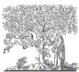

ELSEVIER

Contents lists available at ScienceDirect

Ceramics International

journal homepage: www.elsevier.com/locate/ceramint

CERAMICS INTERNATIONAL

# Extrusion-based 3D direct ink writing of NiZn-ferrite structures with viscoelastic ceramic suspension

Taekyu Anᵃ, Kwang-Taek Hwangᵇ, Jin-Ho Kimᵇ, Jihoon Kimᵃ,*

ᵃ Division of Advanced Materials Engineering, Kongju National University, Cheonan, Chungchungnam-do, 32588, South Korea
ᵇ Icheon Branch, Korea Institute of Ceramic Engineering & Technology (KICET), Icheon-si, Gyeonggi-do, 17303, South Korea

# ARTICLE INFO

Keywords:

Direct ink writing

Auger-extrusion

NiZn-Ferrite

Magnetic core

Ceramic 3D printing

# ABSTRACT

Advances in additive manufacturing (AM), represented as the instant evolution of design files into fully functional products, provide customer-centric smart manufacturing solutions that are increasingly replacing traditional manufacturing methods in various industries. However, the advantages of AM often diminish when applied to the production of ceramic components, owing to the demanding nature of ceramic materials. Extrusion-based direct ink writing (DIW) is considered one of the few AM technologies applicable to ceramic materials. Precise control of the ceramic suspension is required in extrusion-based 3D DIW to create 3D structures for various industrial products. This study describes a fundamental relationship between the rheological properties of the ceramic suspensions and their 3D DIW printability. The rheological properties determine flowability, DIW height, and the overhang angle that can be achieved in extrusion-based 3D DIW. The printability of NiZn-ferrite suspen

...[truncated]

In [7]:
# Display first 2000 characters of the extracted markdown
display(Markdown(paper_markdown[:5000] + "\n\n...[truncated]"))

### Save extracted markdown for later use

In [8]:
# Save the extracted markdown
with open(DATA_DIR / (PAPER_NAME + ".md"), "w", errors="replace") as f:
    f.write(paper_markdown)

if si_markdown:
    with open(DATA_DIR + SUPPL_NAME + ".md", "w", errors="replace") as f:
        f.write(si_markdown)

print(f"Saved markdown files to {DATA_DIR}")

Saved markdown files to /Users/ribes/phd/lematerial-llm-synthesis/data/rheology


---
## Step 2: Figure Extraction

Extract figures from the markdown text. Figures are embedded as base64 data URIs.

Two segmentation backends are available:

| Backend | Model(s) | Output | Pros | Cons |
|---------|----------|--------|------|------|
| **DINO** | Grounding DINO + ResNet-152 | 28 figure classes | More granular classification | Requires 2 models |
| **Florence** (default) | Florence-2 + LoRA | "quantitative plot" / "qualitative plot" | Single model, end-to-end | Binary classification only |

Each extracted figure includes:
- `base64_data`: The image data
- `figure_class`: Classification label
- `quantitative`: Whether it's a quantitative figure (plot, chart, etc.)
- `context_before` / `context_after`: Surrounding text for context
- `figure_reference`: Reference like "Figure 2a"

In [9]:
from llm_synthesis.transformers.figure_extraction import FigureExtractorMarkdown

# ============================================================================
# Option A: Florence-2 with LoRA - single model for detection + classification
# ============================================================================
# Uses a fine-tuned Florence-2 model from HuggingFace Hub
# Outputs: "quantitative plot" or "qualitative plot"
# Model: https://huggingface.co/amayuelas/plot-visualization-florence-2-lora-32

# This is the default segmenter (see FigureExtractorMarkdown).
figure_extractor_florence = FigureExtractorMarkdown(
    segmenter="florence",
    florence_repo_id="amayuelas/plot-visualization-florence-2-lora-32",
)
figures = figure_extractor_florence.forward(paper_markdown)
print(f"Found {len(figures)} figures in the paper (using Florence-2)")

# You can also use a custom LoRA adapter:
# figure_extractor_custom = FigureExtractorMarkdown(
#     segmenter="florence",
#     florence_repo_id="your-username/your-lora-adapter"
# )

`torch_dtype` is deprecated! Use `dtype` instead!
2026/08/23 15:53:05 WARNING dspy.primitives.module: Calling module.forward(...) on FigureExtractorMarkdown directly is discouraged. Please use module(...) instead.


Found 23 figures in the paper.
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 3 subfigures (Florence).
Segmented 4 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 2 subfigures (Florence).
Segmented 2 subfigures (Florence).
Found 30 figures in the paper (using Florence-2)


In [10]:
# ============================================================================
# Option B: DINO + ResNet - 28 figure classes
# ============================================================================
# Uses Grounding DINO for segmentation and ResNet-152 for classification
# Provides granular figure types: "Bar plots", "Scatter plot", "Microscopy", etc.

figure_extractor = FigureExtractorMarkdown(segmenter="dino")

# Extract figures from the markdown
figures = figure_extractor.forward(paper_markdown)

print(f"Found {len(figures)} figures in the paper (using DINO + ResNet)")

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

2026/08/23 15:54:15 WARNING dspy.primitives.module: Calling module.forward(...) on FigureExtractorMarkdown directly is discouraged. Please use module(...) instead.


Found 23 figures in the paper.


/Users/ribes/phd/lematerial-llm-synthesis/.venv/lib/python3.11/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:93: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Segmented 1 subfigures (DINO).
Segmented 3 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 4 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 2 subfigures (DINO).
Segmented 6 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 2 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 3 subfigures (DINO).
Segmented 1 subfigures (DINO).
Segmented 4 subfigures (DINO).
Segmented 2 subfigures (DINO).
Found 41 figures in the paper (using DINO + ResNet)


### Visualize extracted figures

Figure 1: Quantitative - Class: Bar plots
Reference: Unknown Figure


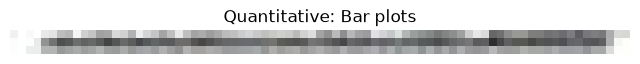

Figure 2: Not Quantitative - Class: Natural images
Reference: Fig. 1


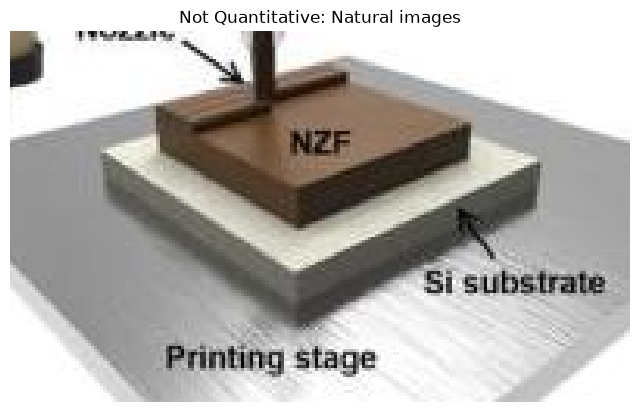

Figure 3: Not Quantitative - Class: Natural images
Reference: Fig. 1


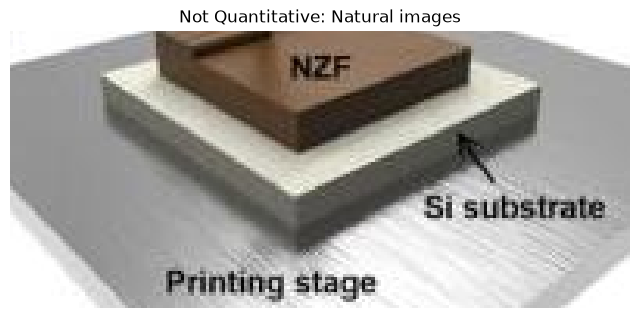

Figure 4: Not Quantitative - Class: Natural images
Reference: Fig. 1


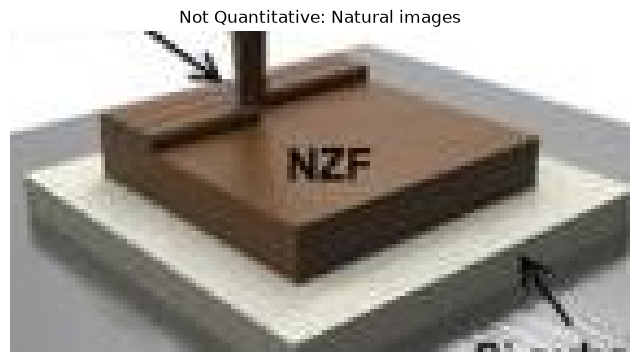

Figure 5: Quantitative - Class: Graph plots
Reference: Fig. 2


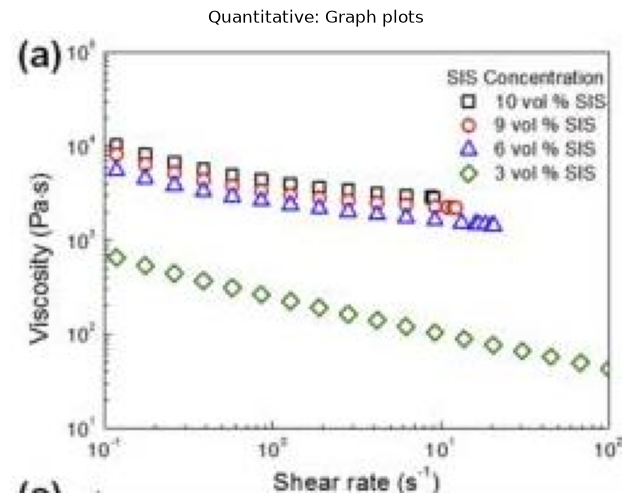

Figure 6: Quantitative - Class: Graph plots
Reference: Fig. 2


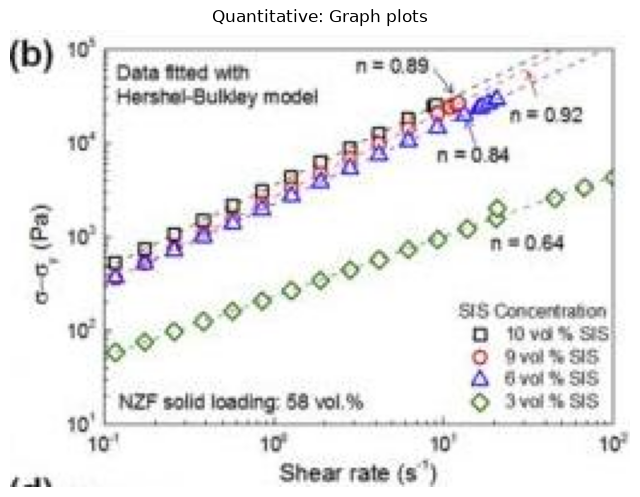

Figure 7: Quantitative - Class: Graph plots
Reference: Fig. 2


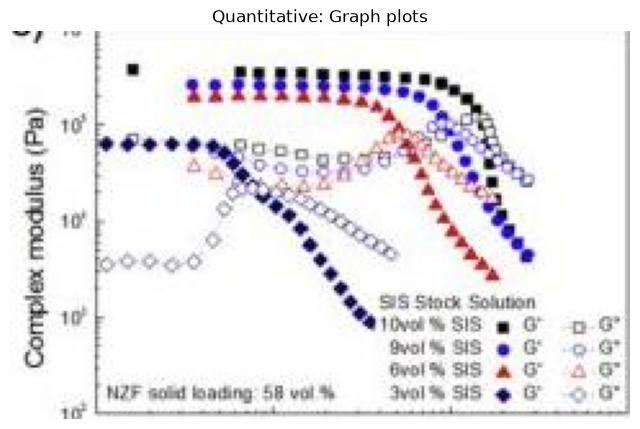

Figure 8: Quantitative - Class: Graph plots
Reference: Fig. 2


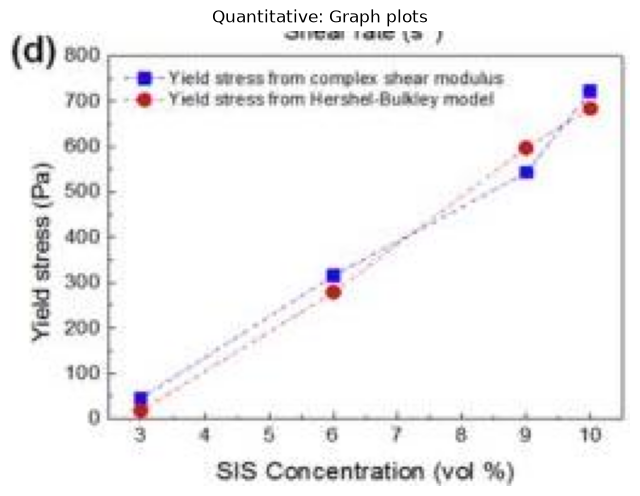

Figure 9: Quantitative - Class: Scatter plot
Reference: Fig. 3


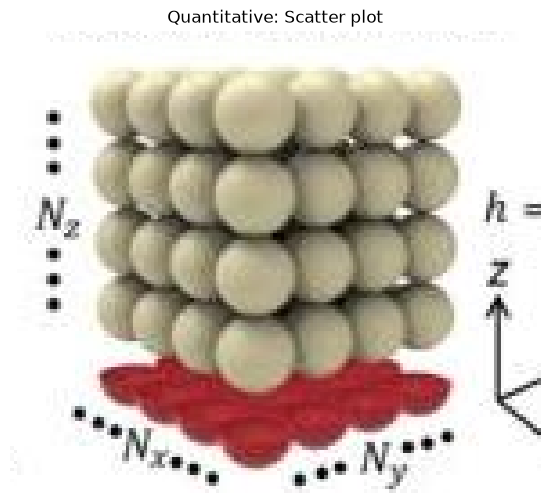

Figure 10: Quantitative - Class: Heat map
Reference: Fig. 3


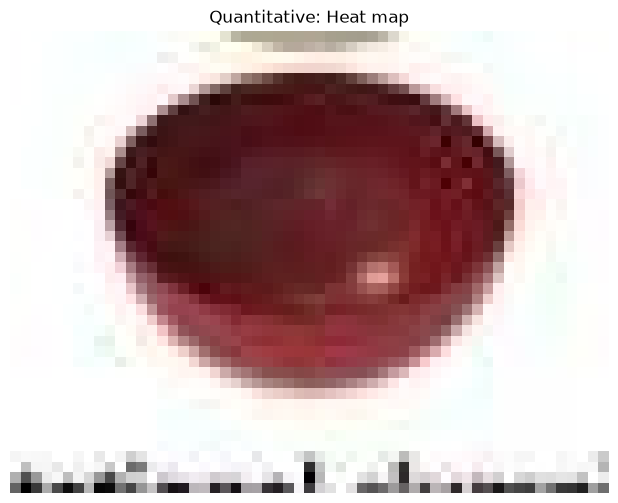

Figure 11: Not Quantitative - Class: 3D objects
Reference: Fig. 3


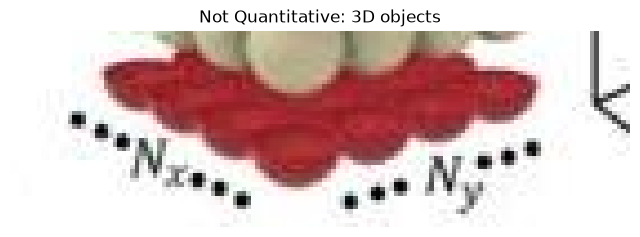

Figure 12: Not Quantitative - Class: 3D objects
Reference: Fig. 3


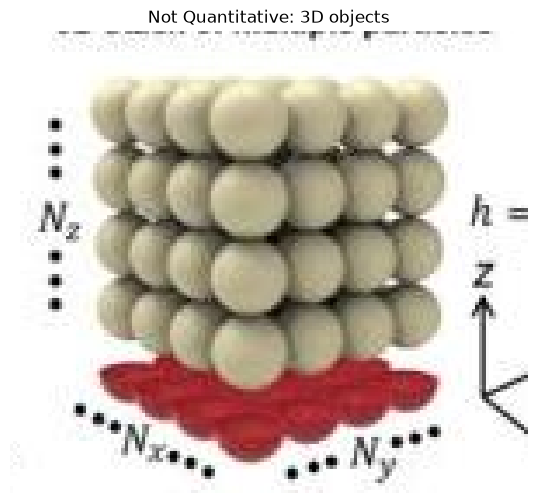

Figure 13: Quantitative - Class: Graph plots
Reference: Fig. 4


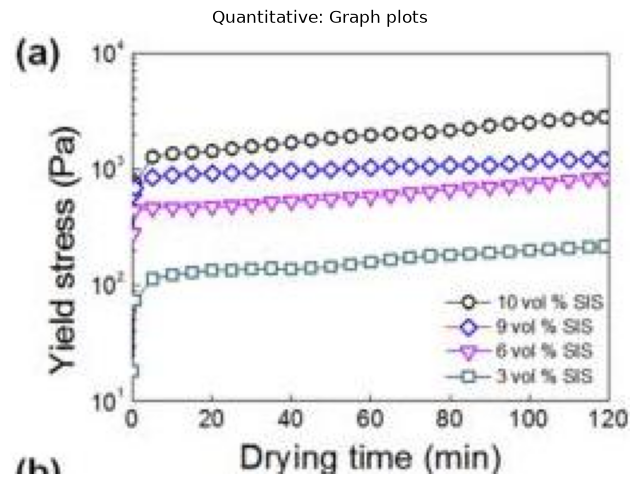

Figure 14: Quantitative - Class: Graph plots
Reference: Fig. 4


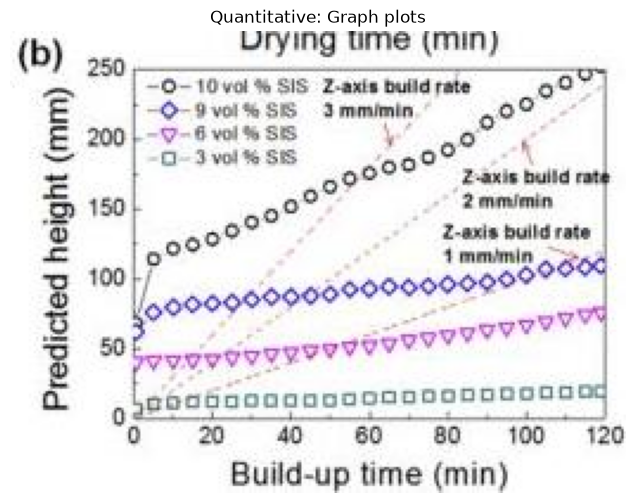

Figure 15: Quantitative - Class: Graph plots
Reference: Fig. 5


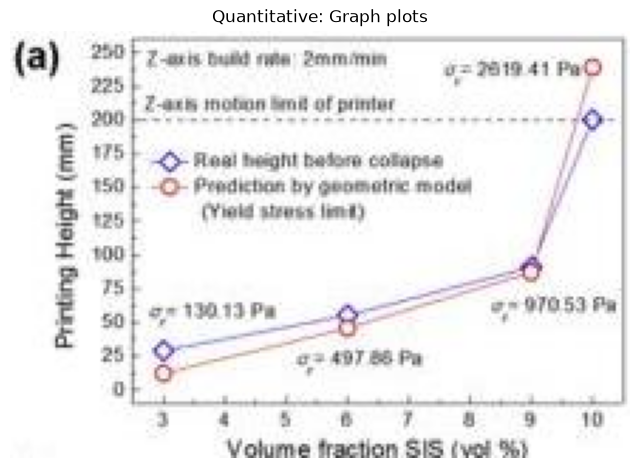

Figure 16: Not Quantitative - Class: Natural images
Reference: Fig. 5


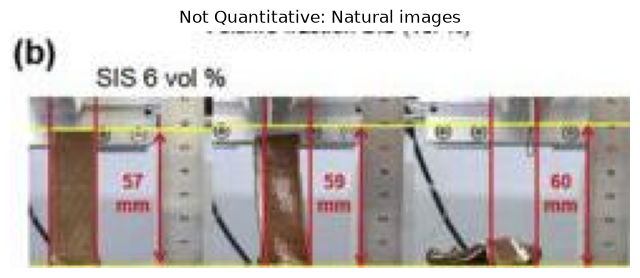

Figure 17: Not Quantitative - Class: Natural images
Reference: Fig. 5


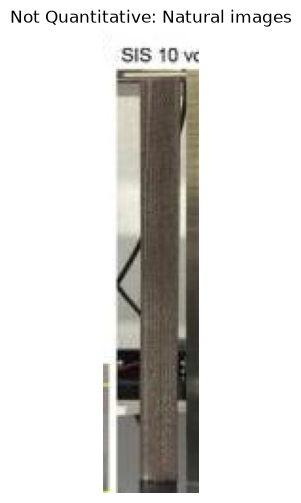

Figure 18: Not Quantitative - Class: Algorithm
Reference: Fig. 6


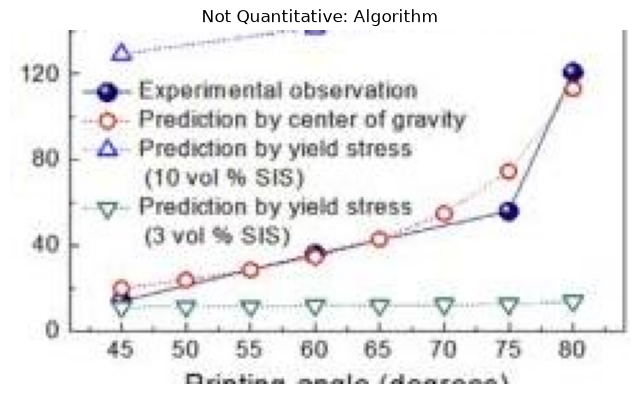

Figure 19: Not Quantitative - Class: Medical images
Reference: Fig. 6


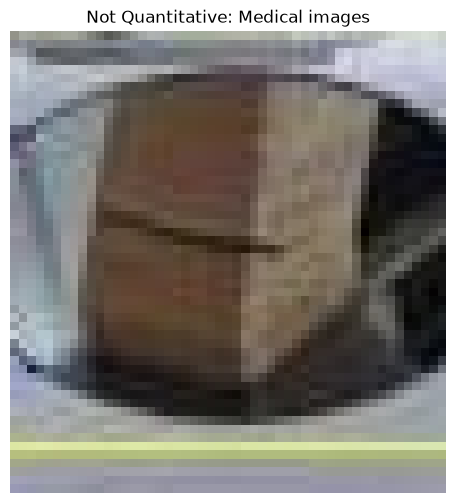

Figure 20: Not Quantitative - Class: Natural images
Reference: Fig. 6


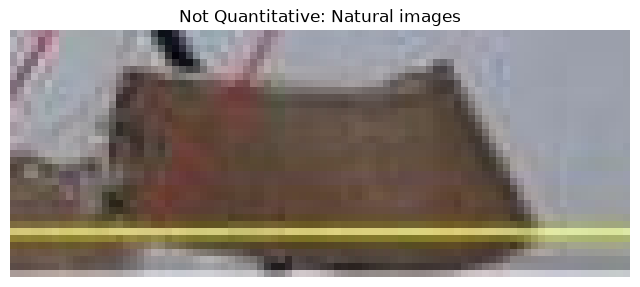

Figure 21: Not Quantitative - Class: Natural images
Reference: Fig. 6


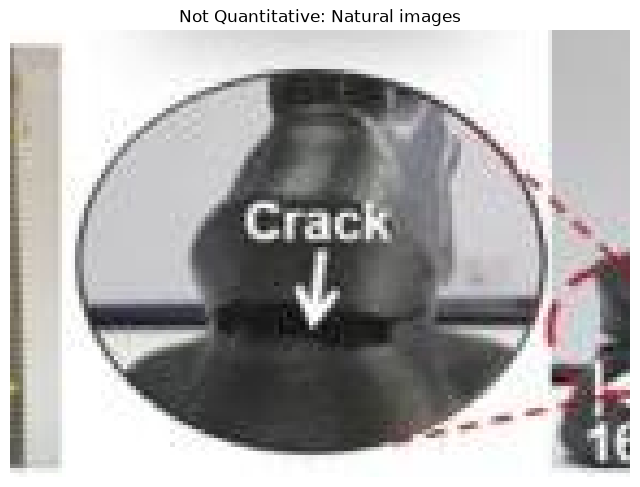

Figure 22: Not Quantitative - Class: Medical images
Reference: Fig. 6


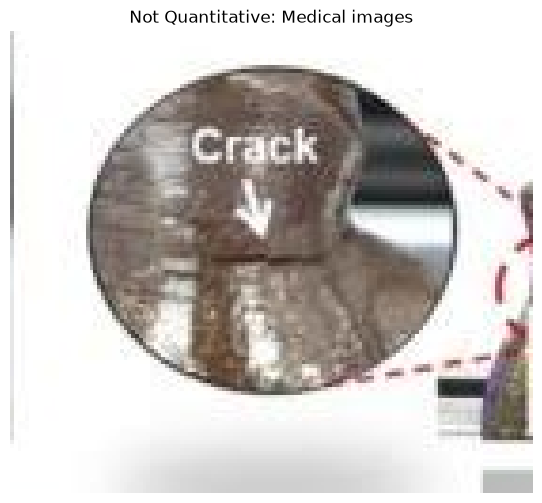

Figure 23: Not Quantitative - Class: Natural images
Reference: Fig. 6


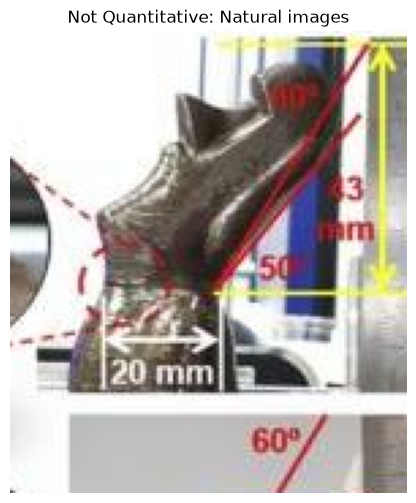

Figure 24: Not Quantitative - Class: Natural images
Reference: Fig. 6


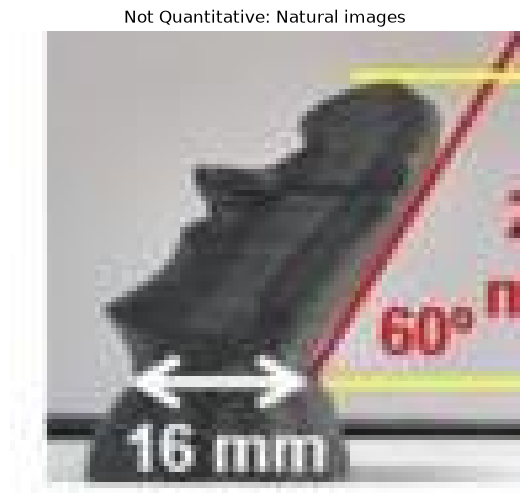

Figure 25: Not Quantitative - Class: Sketches
Reference: Fig. 6


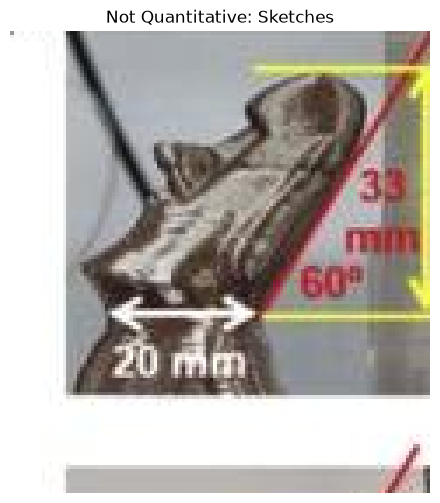

Figure 26: Not Quantitative - Class: Natural images
Reference: Fig. 6


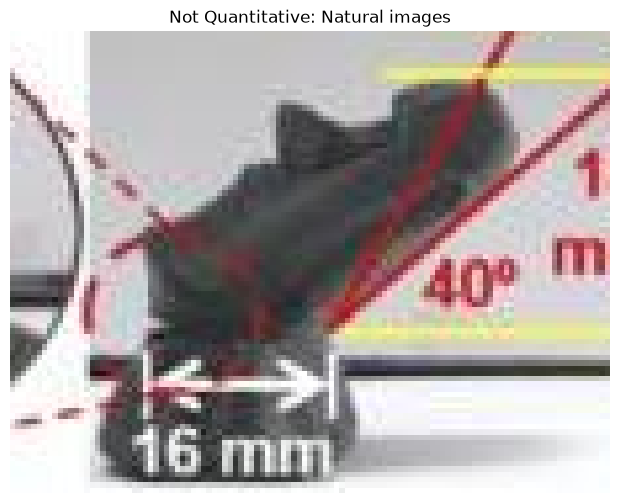

Figure 27: Quantitative - Class: Graph plots
Reference: Fig. 7


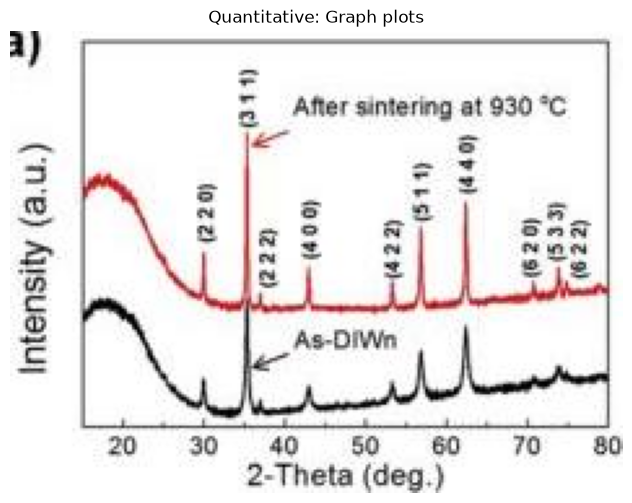

Figure 28: Not Quantitative - Class: Natural images
Reference: Fig. 7


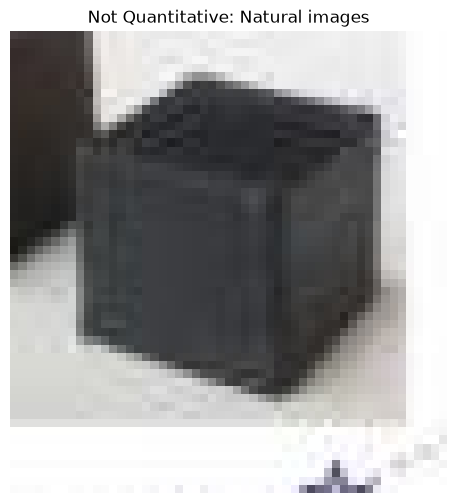

Figure 29: Not Quantitative - Class: 3D objects
Reference: Fig. 7


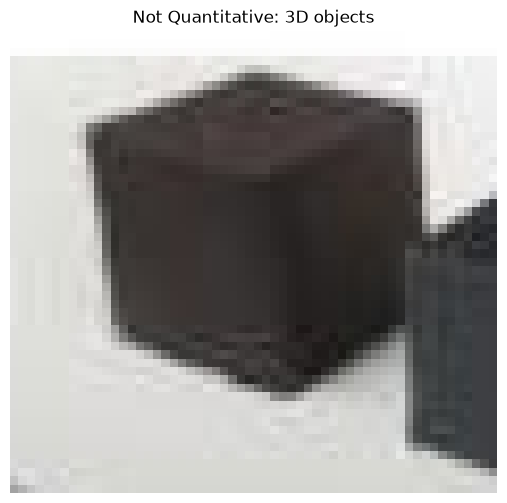

Figure 30: Not Quantitative - Class: Medical images
Reference: Fig. 7


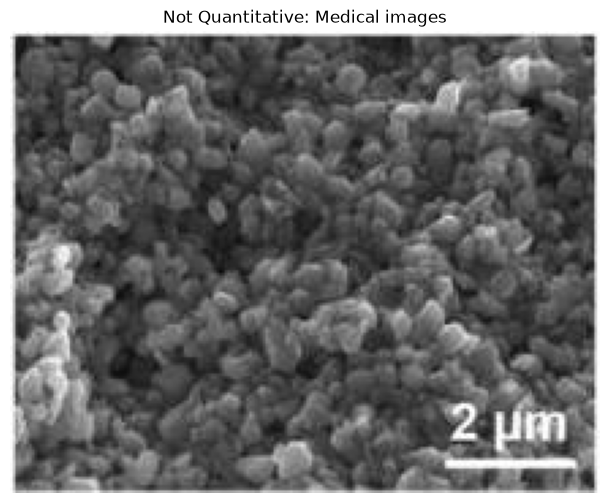

Figure 31: Not Quantitative - Class: Natural images
Reference: Fig. 7


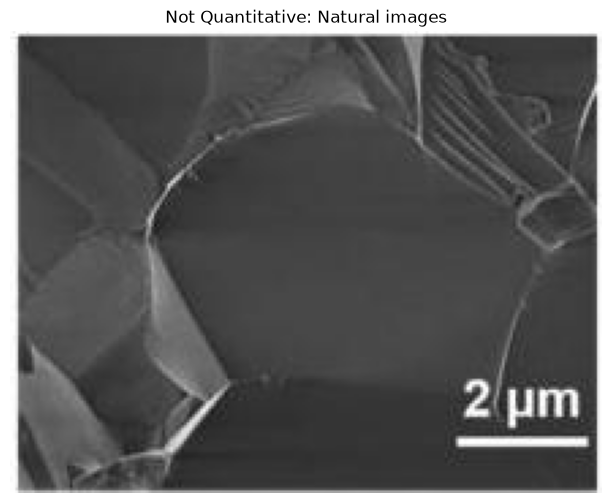

Figure 32: Not Quantitative - Class: Natural images
Reference: Fig. 8


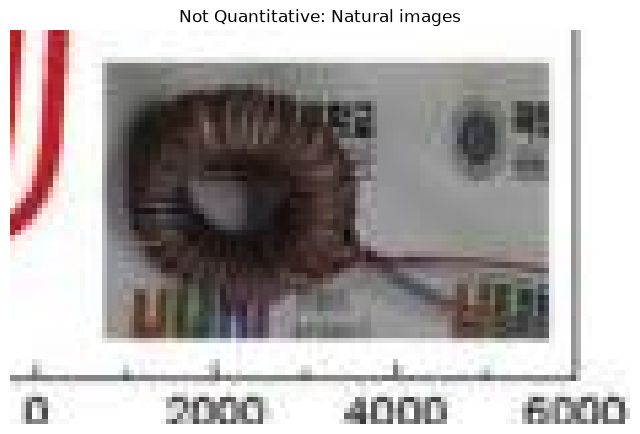

Figure 33: Not Quantitative - Class: Natural images
Reference: Fig. 8


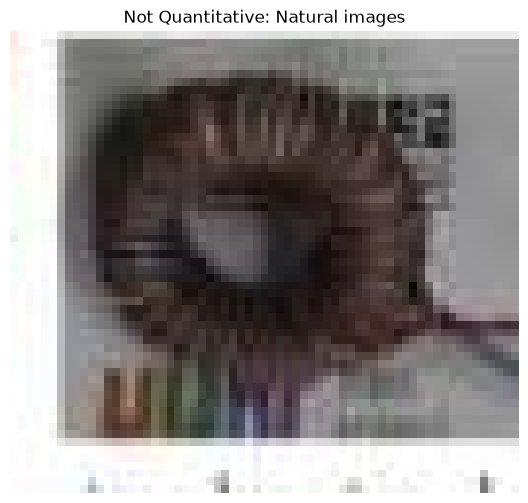

Figure 34: Not Quantitative - Class: Medical images
Reference: Fig. 8


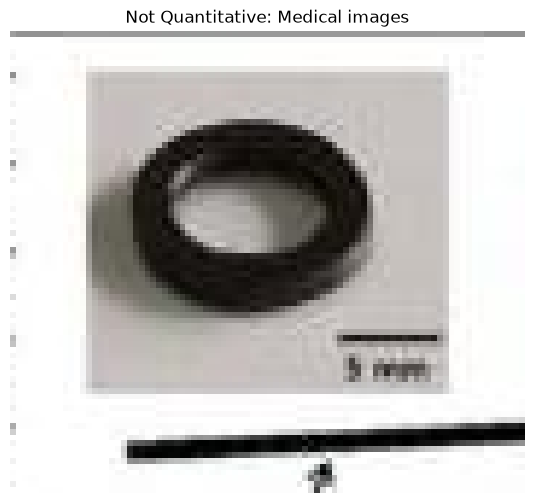

Figure 35: Quantitative - Class: Graph plots
Reference: Fig. 8


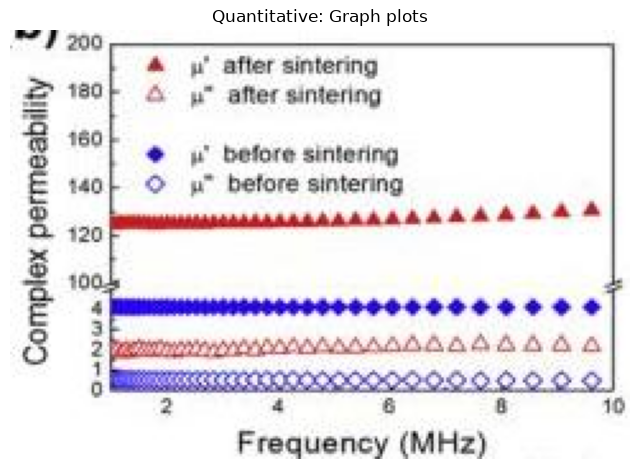

Figure 36: Not Quantitative - Class: Natural images
Reference: Fig. 8


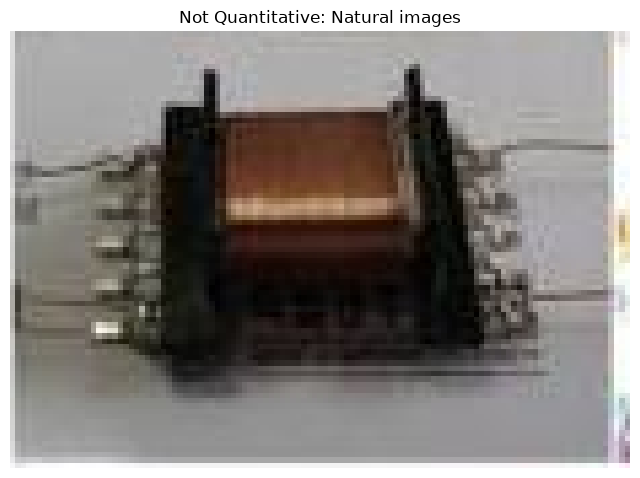

Figure 37: Not Quantitative - Class: Natural images
Reference: Fig. 8


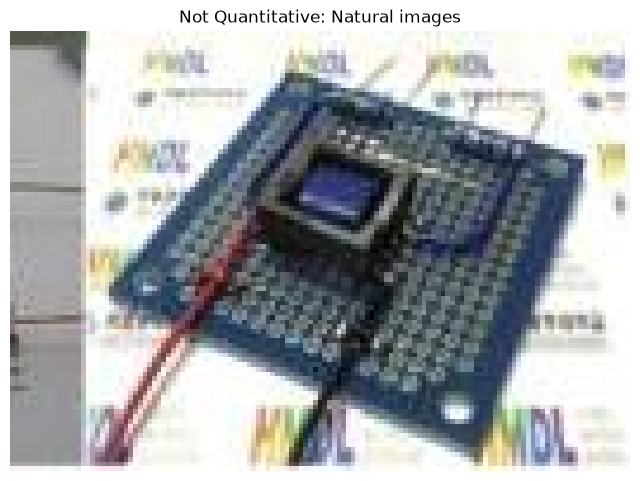

Figure 38: Not Quantitative - Class: Natural images
Reference: Fig. 8


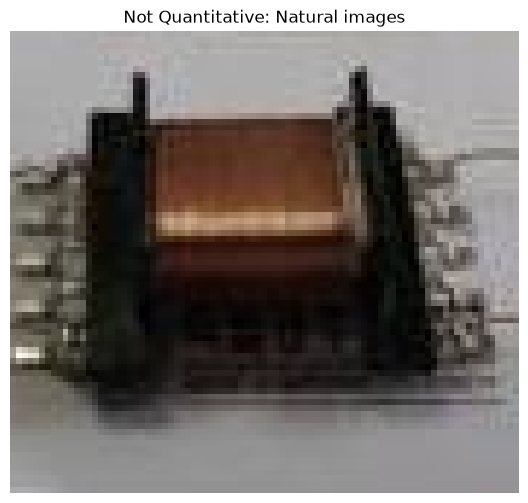

Figure 39: Not Quantitative - Class: Natural images
Reference: Fig. 8


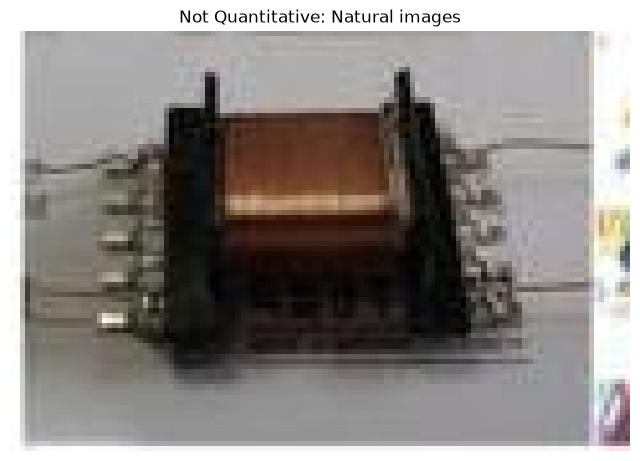

Figure 40: Quantitative - Class: Graph plots
Reference: Fig. 8


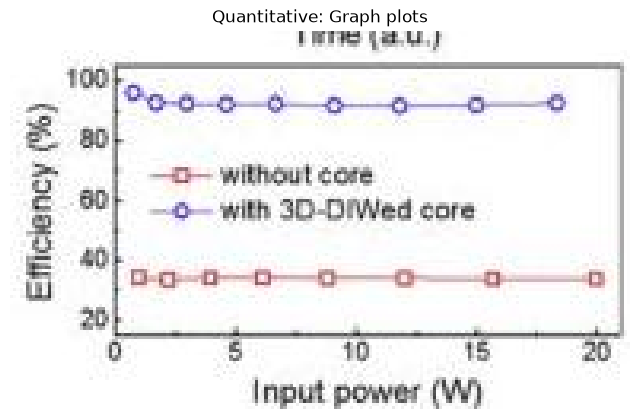

Figure 41: Quantitative - Class: Bar plots
Reference: Fig. 8


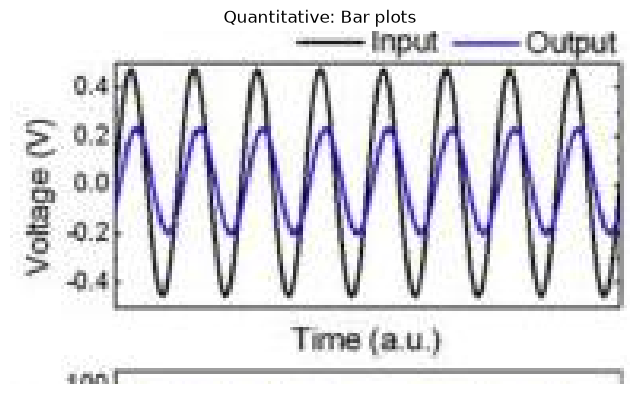

In [11]:
# Display all extracted figures with their classifications
for idx, figure in enumerate(figures):
    print("=" * 80)
    is_quantitative = (
        "Quantitative" if figure.quantitative else "Not Quantitative"
    )
    print(f"Figure {idx + 1}: {is_quantitative} - Class: {figure.figure_class}")
    print(f"Reference: {figure.figure_reference}")

    # Decode and display the image
    image_data = base64.b64decode(figure.base64_data)
    image = PILImage.open(io.BytesIO(image_data))

    plt.figure(figsize=(8, 6))
    plt.imshow(np.array(image))
    plt.axis("off")
    plt.title(f"{is_quantitative}: {figure.figure_class}")
    plt.show()

### Inspect figure metadata

In [12]:
# Print metadata for the first figure
if figures:
    fig = figures[0]
    print("Figure Reference:", fig.figure_reference)
    print("Figure Class:", fig.figure_class)
    print("Quantitative:", fig.quantitative)
    print("Position in text:", fig.position)
    print("\nAlt Text:", fig.alt_text[:200] if fig.alt_text else "None")
    print(
        "\nContext Before:",
        fig.context_before[:200] if fig.context_before else "None",
    )
    print(
        "\nContext After:",
        fig.context_after[:200] if fig.context_after else "None",
    )

Figure Reference: Unknown Figure
Figure Class: Bar plots
Quantitative: True
Position in text: 44

Alt Text: fig

Context Before: Ceramics International 46 (2020) 6469–6476



Context After: ![fig](placeholder_image)

ELSEVIER

Contents lists available at ScienceDirect

Ceramics International

journal homepage: www.elsevier.com/locate/ceramint

CERAMICS INTERNATIONAL

# Extrusion-based 3D


---
## Step 3: Text Cleaning

Clean the extracted text by removing figures and references for better material/synthesis extraction.

Available utilities:
- `clean_text()`: Removes both figures and references
- `remove_figs()`: Removes only figure markdown
- `remove_references()`: Removes only reference sections

In [13]:
from llm_synthesis.utils.markdown_utils import clean_text

# Clean the paper text
clean_paper_text = clean_text(paper_markdown)
clean_si_text = clean_text(si_markdown) if si_markdown else ""

print(f"Original length: {len(paper_markdown)} characters")
print(f"Cleaned length: {len(clean_paper_text)} characters")
print(f"Removed: {len(paper_markdown) - len(clean_paper_text)} characters")

Original length: 344335 characters
Cleaned length: 33145 characters
Removed: 311190 characters


### Create Paper object

The `Paper` model holds the paper metadata and text content:

In [14]:
from llm_synthesis.models.paper import Paper

paper = Paper(
    id=PAPER_ID,
    name=PAPER_NAME,
    publication_text=clean_paper_text,
    si_text=clean_si_text,
)

print(f"Created Paper object: {paper.name} (ID: {paper.id})")

Created Paper object: an_2020 (ID: an_2020)


---
## Step 4: Material Extraction

Extract the list of synthesized materials from the paper text using LLM-based extraction.

The extractor uses DSPy with configurable LLM backends:
- `gemini-2.0-flash`, `gemini-2.5-flash`, `gemini-2.5-pro` (Google)
- `gpt-4o`, `gpt-4o-mini` (OpenAI)
- `mistral-small`, `mistral-medium`, `mistral-large` (Mistral)

In [16]:
from llm_synthesis.transformers.material_extraction import (
    DspyTextExtractor,
    make_dspy_text_extractor_signature,
)
from llm_synthesis.utils.dspy_utils import get_llm_from_name

# Create a signature for material extraction
material_signature = make_dspy_text_extractor_signature(
    signature_name="TextToMaterials",
    instructions=(
        "Extract ONLY the final synthesized materials from the publication text. "
        "Focus on materials that were actually synthesized in the paper, not just mentioned. "
        "Return materials as chemical formulas when possible."
    ),
    input_description="The publication text to extract synthesized materials from.",
    output_name="materials",
    output_description=(
        "The final synthesized materials as a comma-separated list using chemical formulas "
        "(e.g., 'Ru/CeO2, Ni-Mo/Al2O3'). Never use common names alone."
    ),
)

# Initialize the LLM
material_lm = get_llm_from_name(
    llm_name="gemini-3.0-flash",  # Highest quality with "gemini-3.0-pro"; "gemini-3.0-flash" is cheaper
    model_kwargs={"temperature": 0.0},
)

# Create the material extractor
material_extractor = DspyTextExtractor(
    signature=material_signature,
    lm=material_lm,
)

In [19]:
# Extract materials from the paper
materials_text = material_extractor.forward(input=clean_paper_text)

# Parse the comma-separated list into individual materials
materials = [
    material.strip()
    for material in materials_text.replace("\n", ",").split(",")
    if material.strip()
]

print(f"Found {len(materials)} materials:")
for i, material in enumerate(materials, 1):
    print(f"  {i}. {material}")

2026/08/23 16:03:20 WARNING dspy.primitives.module: Calling module.forward(...) on DspyTextExtractor directly is discouraged. Please use module(...) instead.


Found 1 materials:
  1. Ni0.4Zn0.6Fe2O4


---
## Step 5: Synthesis Extraction

Extract structured synthesis procedures for each material.

The output is a `GeneralSynthesisOntology` object containing:
- **target_compound**: The material being synthesized
- **target_compound_type**: Category (e.g., "nanomaterials", "ceramics")
- **synthesis_method**: Method used (e.g., "hydrothermal", "sol-gel")
- **starting_materials**: List of precursors with amounts
- **steps**: Ordered list of synthesis steps with conditions
- **equipment**: List of equipment used

**Note:** The enum fields (`synthesis_method`, `target_compound_type`) are closed `Literal` sets, so the system prompt below repeats the allowed values. Without it, models frequently invent values and the Pydantic validation fails.

In [20]:
from llm_synthesis.transformers.synthesis_extraction import (
    DspySynthesisExtractor,
    make_dspy_synthesis_extractor_signature,
)

# System prompt to guide the model on valid enum values
SYNTHESIS_SYSTEM_PROMPT = """You are a helpful assistant that extracts structured synthesis procedures from scientific papers.

IMPORTANT: For the synthesis_method field, you MUST choose from these exact values:
'PVD', 'CVD', 'arc discharge', 'ball milling', 'spray pyrolysis', 'electrospinning', 
'sol-gel', 'hydrothermal', 'solvothermal', 'precipitation', 'coprecipitation', 'combustion', 
'microwave-assisted', 'sonochemical', 'template-directed', 'solid-state', 'flux growth', 
'float zone & Bridgman', 'arc melting & induction melting', 'spark plasma sintering', 
'electrochemical deposition', 'chemical bath deposition', 'liquid-phase epitaxy', 'self-assembly', 
'atomic layer deposition', 'molecular beam epitaxy', 'pulsed laser deposition', 'ion implantation', 
'lithographic patterning', 'wet impregnation', 'incipient wetness impregnation', 'mechanical mixing', 
'solution-based', 'mechanochemical', 'other'

For the target_compound_type field, you MUST choose from these exact values:
'metals & alloys', 'ceramics & glasses', 'polymers & soft matter', 'composites', 
'semiconductors & electronic', 'nanomaterials', 'two-dimensional materials', 
'framework & porous materials', 'biomaterials & biological', 'liquid materials', 
'hybrid & organic-inorganic', 'functional materials & catalysts', 'energy & sustainability', 
'smart & responsive materials', 'emerging & quantum materials', 'other'

If the exact method is not in the list, use the closest match or 'other'."""

# Create a signature for synthesis extraction
synthesis_signature = make_dspy_synthesis_extractor_signature(
    signature_name="ExtractStructuredSynthesis",
    instructions=(
        "Extract the complete structured synthesis procedure for the specified material. "
        "Include all steps, conditions (temperature, time, atmosphere), equipment, and precursors. "
        "Be thorough and preserve all quantitative details."
    ),
    paper_text_description="The complete paper text containing synthesis procedures.",
    material_name_description="The specific material to extract the synthesis procedure for.",
    output_name="structured_synthesis",
    output_description="The complete structured synthesis procedure for the material.",
)

# Initialize the LLM - use gpt-4o-mini for better structured output support
synthesis_lm = get_llm_from_name(
    llm_name="gemini-3.0-flash",  # Registry alias -> gemini/gemini-3-flash-preview
    model_kwargs={
        "temperature": 0.0,
        "max_tokens": 60000,
    },
    system_prompt=SYNTHESIS_SYSTEM_PROMPT,
)

# Create the synthesis extractor
synthesis_extractor = DspySynthesisExtractor(
    signature=synthesis_signature,
    lm=synthesis_lm,
)

In [21]:
from llm_synthesis.models.paper import SynthesisEntry

# Extract synthesis for each material
all_syntheses = []

for material in materials:
    print(f"\nExtracting synthesis for: {material}")
    print("-" * 50)

    try:
        # The extractor takes a tuple of (paper_text, material_name)
        synthesis = synthesis_extractor.forward(
            input=(clean_paper_text, material)
        )

        # Store the result
        all_syntheses.append(
            SynthesisEntry(
                material=material,
                synthesis=synthesis,
                evaluation=None,  # Optional: add judge evaluation
            )
        )

        print(f"  Method: {synthesis.synthesis_method}")
        print(f"  Type: {synthesis.target_compound_type}")
        print(f"  Steps: {len(synthesis.steps)}")
        print(f"  Starting materials: {len(synthesis.starting_materials)}")

    except Exception as e:
        print(f"  Error: {e}")

print(f"\nSuccessfully extracted {len(all_syntheses)} synthesis procedures")

2026/08/23 16:03:56 WARNING dspy.primitives.module: Calling module.forward(...) on DspySynthesisExtractor directly is discouraged. Please use module(...) instead.



Extracting synthesis for: Ni0.4Zn0.6Fe2O4
--------------------------------------------------
  Method: other
  Type: ceramics & glasses
  Steps: 9
  Starting materials: 3

Successfully extracted 1 synthesis procedures


### Inspect a synthesis result

In [25]:
# Display the first synthesis in detail
if all_syntheses:
    synthesis = all_syntheses[0].synthesis

    print(f"Target Compound: {synthesis.target_compound}")
    print(f"Compound Type: {synthesis.target_compound_type}")
    print(f"Synthesis Method: {synthesis.synthesis_method}")

    print("\nStarting Materials:")
    for mat in synthesis.starting_materials:
        print(f"  - {mat.name}: {mat.amount} {mat.unit}")

    print("\nSynthesis Steps:")
    for step in synthesis.steps:
        print(f"  {step.step_number}. {step.action}")
        if step.conditions:
            if step.conditions.temperature:
                print(
                    f"      Temperature: {step.conditions.temperature} {step.conditions.temp_unit}"
                )
            if step.conditions.duration:
                print(
                    f"      Duration: {step.conditions.duration} {step.conditions.time_unit}"
                )

    print("\nEquipment:")
    for eq in synthesis.equipment:
        print(f"  - {eq.name}")

Target Compound: Ni0.4Zn0.6Fe2O4
Compound Type: ceramics & glasses
Synthesis Method: other

Starting Materials:
  - Polystyrene-polyisoprene-polystyrene (SIS): None None
  - n-methyl-2-pyrrolidone (NMP): None None
  - Ni0.4Zn0.6Fe2O4 nanoparticles: None None

Synthesis Steps:
  1. dissolve
  2. mix
      Duration: 5.0 min
  3. centrifuge
      Duration: 1.0 min
  4. add
  5. mix
  6. centrifuge
      Duration: 30.0 s
  7. add
      Temperature: 25.0 C
  8. dry
      Temperature: 60.0 C
      Duration: 24.0 h
  9. calcine
      Temperature: 930.0 C
      Duration: 5.0 h

Equipment:
  - Thinky mixer
  - Auger dispenser
  - 3D printing stage
  - Box furnace
  - Rheometer


### Export synthesis as JSON

In [26]:
import json

# Export all syntheses to JSON
if all_syntheses:
    synthesis_dict = all_syntheses[0].synthesis.model_dump()
    print(json.dumps(synthesis_dict, indent=2))

{
  "target_compound": "Ni0.4Zn0.6Fe2O4",
  "target_compound_type": "ceramics & glasses",
  "synthesis_method": "other",
  "starting_materials": [
    {
      "vendor": "Sigma Aldrich",
      "name": "Polystyrene-polyisoprene-polystyrene (SIS)",
      "amount": null,
      "unit": null,
      "purity": "22% styrene"
    },
    {
      "vendor": null,
      "name": "n-methyl-2-pyrrolidone (NMP)",
      "amount": null,
      "unit": null,
      "purity": null
    },
    {
      "vendor": "Amotech",
      "name": "Ni0.4Zn0.6Fe2O4 nanoparticles",
      "amount": null,
      "unit": null,
      "purity": "D50 = 500 nm"
    }
  ],
  "steps": [
    {
      "step_number": 1,
      "action": "dissolve",
      "description": "Dissolve SIS powder in NMP at a weight ratio of SIS:NMP = 1:2.5 to make a stock solution.",
      "materials": [
        {
          "vendor": "Sigma Aldrich",
          "name": "SIS",
          "amount": 1.0,
          "unit": "weight ratio",
          "purity": "22% styre

---
## Step 6: Create Final Result Object

Combine all extracted data into a `PaperWithSynthesisOntologies` object:

In [27]:
from llm_synthesis.models.paper import PaperWithSynthesisOntologies

# Create the final result object
result = PaperWithSynthesisOntologies(
    name=paper.name,
    id=paper.id,
    publication_text=paper.publication_text,
    si_text=paper.si_text,
    all_syntheses=all_syntheses,
    cost_data=None,  # Cost tracking is available in production scripts
)

print(f"Created result for paper: {result.name}")
print(f"Total materials: {len(result.all_syntheses)}")
print(f"Total figures: {len(figures)}")

Created result for paper: an_2020
Total materials: 1
Total figures: 41


### Save results

In [29]:
import json
import os

# Save the complete result as JSON
output_dir = DATA_DIR / "results/"
os.makedirs(output_dir, exist_ok=True)

output_path = output_dir / (PAPER_ID + ".json")
with open(output_path, "w") as f:
    json.dump(result.model_dump(), f, indent=2)

print(f"Saved results to: {output_path}")

Saved results to: /Users/ribes/phd/lematerial-llm-synthesis/data/rheology/results/an_2020.json


---
## Figure Data Extraction with Claude

Extract numerical coordinate data from quantitative figures (plots, charts) using Claude's vision API.

This is useful for:
- Extracting data points from line plots, scatter plots, bar charts
- Digitizing figure data for further analysis
- Converting visual data back to tabular format

**Requirements:** `ANTHROPIC_API_KEY` environment variable must be set.

In [37]:
from llm_synthesis.models.figure import FigureInfoWithPaper
from llm_synthesis.transformers.plot_extraction.claude_extraction.plot_data_extraction import (
    ClaudeLinePlotDataExtractor,
)

# Initialize the Claude coordinate extractor
# The model name must contain "sonnet", "opus", "haiku-3" or "haiku-35" -
# ClaudeAPIClient uses it to select its price table and raises
# ValueError: Unsupported model otherwise.
coordinate_extractor = ClaudeLinePlotDataExtractor(
    model_name="claude-sonnet-4-6",
    max_tokens=2048,
    temperature=0.0,
)

print("Claude coordinate extractor initialized")

Claude coordinate extractor initialized


In [38]:
# Select a quantitative figure for data extraction
# Filter to only quantitative figures (plots, charts, etc.)
quantitative_figures = [f for f in figures if f.quantitative]

print(f"Found {len(quantitative_figures)} quantitative figures:")
for i, fig in enumerate(quantitative_figures):
    print(f"  [{i}] {fig.figure_reference} - {fig.figure_class}")

# Select which figure to extract data from (change index as needed)
FIGURE_INDEX = 7  # Change this to select a different figure

Found 14 quantitative figures:
  [0] Unknown Figure - Bar plots
  [1] Fig. 2 - Graph plots
  [2] Fig. 2 - Graph plots
  [3] Fig. 2 - Graph plots
  [4] Fig. 2 - Graph plots
  [5] Fig. 3 - Scatter plot
  [6] Fig. 3 - Heat map
  [7] Fig. 4 - Graph plots
  [8] Fig. 4 - Graph plots
  [9] Fig. 5 - Graph plots
  [10] Fig. 7 - Graph plots
  [11] Fig. 8 - Graph plots
  [12] Fig. 8 - Graph plots
  [13] Fig. 8 - Bar plots


Selected: Fig. 4 - Graph plots
Context: tween the surface tension and the slumping force from the yield stress of the NZF suspension is shown in Fig. S1 of the supplementary information.

The final aspect to consider regarding the yield str...


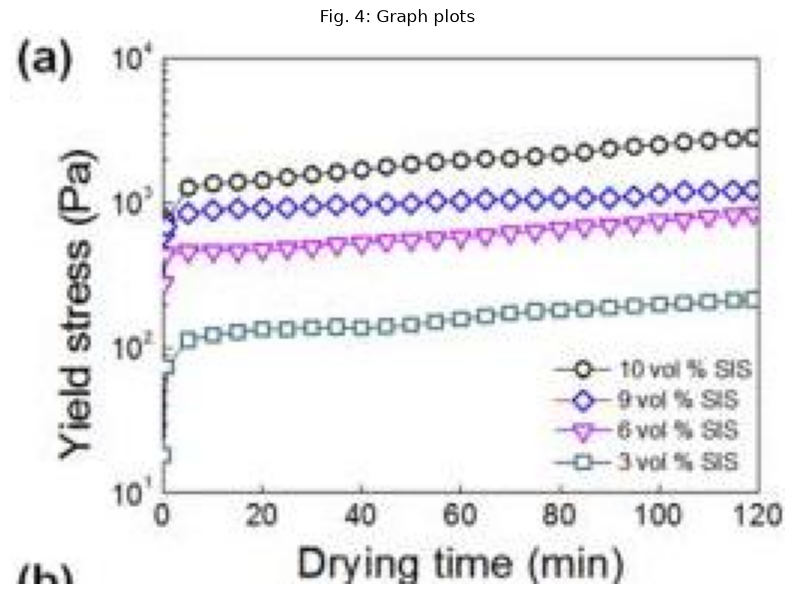

In [39]:
# Display the selected figure
if quantitative_figures:
    selected_figure = quantitative_figures[FIGURE_INDEX]

    print(
        f"Selected: {selected_figure.figure_reference} - {selected_figure.figure_class}"
    )
    print(
        f"Context: {selected_figure.context_before[:200] if selected_figure.context_before else 'None'}..."
    )

    # Display the figure
    image_data = base64.b64decode(selected_figure.base64_data)
    image = PILImage.open(io.BytesIO(image_data))

    plt.figure(figsize=(10, 8))
    plt.imshow(np.array(image))
    plt.axis("off")
    plt.title(
        f"{selected_figure.figure_reference}: {selected_figure.figure_class}"
    )
    plt.show()
else:
    print("No quantitative figures found in this paper")

### Extract coordinate data from the figure

Now we'll use Claude's vision API to extract the numerical data points from the plot:

In [40]:
# Extract coordinate data from the selected figure
if quantitative_figures:
    selected_figure = quantitative_figures[FIGURE_INDEX]

    # Create FigureInfoWithPaper object (required by the extractor)
    figure_with_context = FigureInfoWithPaper(
        base64_data=selected_figure.base64_data,
        alt_text=selected_figure.alt_text or "",
        position=selected_figure.position,
        context_before=selected_figure.context_before or "",
        context_after=selected_figure.context_after or "",
        figure_reference=selected_figure.figure_reference or "",
        figure_class=selected_figure.figure_class or "",
        quantitative=selected_figure.quantitative,
        paper_text=clean_paper_text,
        si_text=clean_si_text,
    )

    print("Extracting coordinate data with Claude...")
    print("This may take a few seconds...\n")

    # Extract the data
    extracted_plot_data = coordinate_extractor.forward(figure_with_context)

    # Print extraction cost
    cost = coordinate_extractor.get_cost()
    print(f"Extraction cost: ${cost:.4f}")
else:
    print("No quantitative figures to extract data from")

2026/08/23 16:13:27 WARNING dspy.primitives.module: Calling module.forward(...) on ClaudeLinePlotDataExtractor directly is discouraged. Please use module(...) instead.


Extracting coordinate data with Claude...
This may take a few seconds...

Extraction cost: $0.0094


### View extracted plot metadata and data

In [41]:
# Display extracted plot metadata
if quantitative_figures and extracted_plot_data:
    print("=== Extracted Plot Metadata ===")
    print(f"Title: {extracted_plot_data.title}")
    print(
        f"X-axis: {extracted_plot_data.x_axis_label} ({extracted_plot_data.x_axis_unit})"
    )
    print(
        f"Y-axis (left): {extracted_plot_data.y_left_axis_label} ({extracted_plot_data.y_left_axis_unit})"
    )

    print("\n=== Extracted Data Series ===")
    for (
        series_name,
        coordinates,
    ) in extracted_plot_data.name_to_coordinates.items():
        print(f"\n{series_name}: {len(coordinates)} data points")
        # Show first 5 points as preview
        for i, (x, y) in enumerate(coordinates[:5]):
            print(f"  ({x}, {y})")
        if len(coordinates) > 5:
            print(f"  ... and {len(coordinates) - 5} more points")

=== Extracted Plot Metadata ===
Title: Yield stress of the NZF-suspension with various SIS concentration as a function of drying time
X-axis: Drying time (min)
Y-axis (left): Yield stress (Pa)

=== Extracted Data Series ===

Series_Name (10 vol % SIS): 13 data points
  (0.0, 900.0)
  (10.0, 950.0)
  (20.0, 1000.0)
  (30.0, 1050.0)
  (40.0, 1100.0)
  ... and 8 more points

Series_Name (9 vol % SIS): 13 data points
  (0.0, 400.0)
  (10.0, 420.0)
  (20.0, 440.0)
  (30.0, 460.0)
  (40.0, 480.0)
  ... and 8 more points

Series_Name (6 vol % SIS): 13 data points
  (0.0, 150.0)
  (10.0, 160.0)
  (20.0, 170.0)
  (30.0, 180.0)
  (40.0, 190.0)
  ... and 8 more points

Series_Name (3 vol % SIS): 13 data points
  (0.0, 55.0)
  (10.0, 58.0)
  (20.0, 61.0)
  (30.0, 64.0)
  (40.0, 67.0)
  ... and 8 more points


### Visualize extracted data

Plot the extracted data points to verify accuracy:

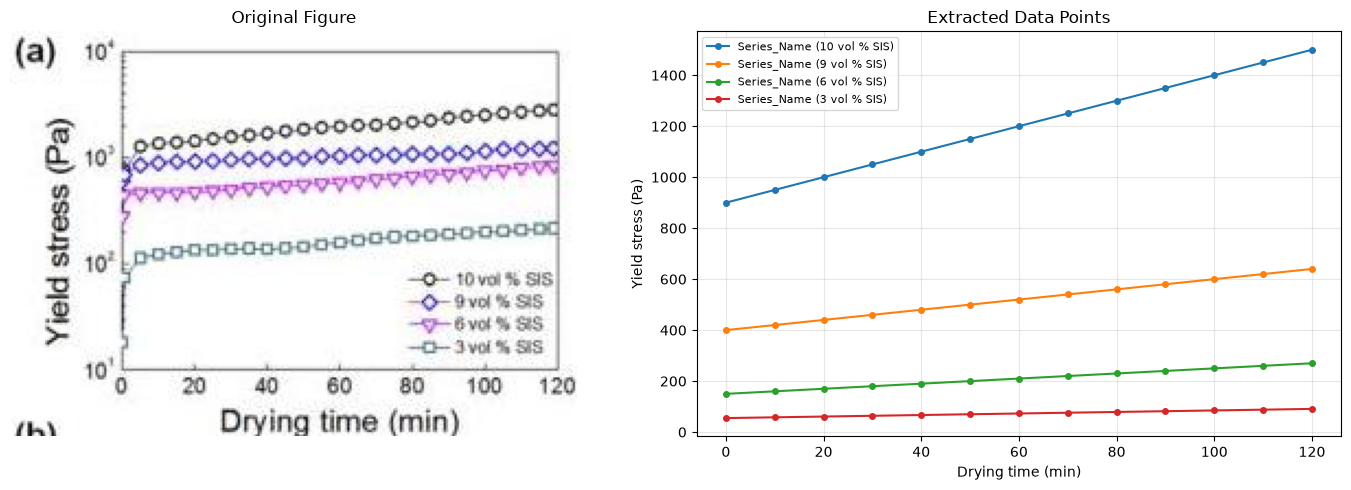

In [42]:
# Visualize the extracted data
if (
    quantitative_figures
    and extracted_plot_data
    and extracted_plot_data.name_to_coordinates
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Original figure
    image_data = base64.b64decode(selected_figure.base64_data)
    image = PILImage.open(io.BytesIO(image_data))
    axes[0].imshow(np.array(image))
    axes[0].set_title("Original Figure")
    axes[0].axis("off")

    # Right: Extracted data points
    colors = plt.cm.tab10.colors
    for i, (series_name, coordinates) in enumerate(
        extracted_plot_data.name_to_coordinates.items()
    ):
        if coordinates:
            x_vals = [coord[0] for coord in coordinates]
            y_vals = [coord[1] for coord in coordinates]
            axes[1].plot(
                x_vals,
                y_vals,
                "o-",
                color=colors[i % len(colors)],
                label=series_name,
                markersize=4,
            )

    axes[1].set_xlabel(
        f"{extracted_plot_data.x_axis_label or 'X'} ({extracted_plot_data.x_axis_unit or ''})"
    )
    axes[1].set_ylabel(
        f"{extracted_plot_data.y_left_axis_label or 'Y'} ({extracted_plot_data.y_left_axis_unit or ''})"
    )
    axes[1].set_title("Extracted Data Points")
    axes[1].legend(loc="best", fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")

### Export extracted data to CSV

In [45]:
import csv

# Export extracted data to CSV
if (
    quantitative_figures
    and extracted_plot_data
    and extracted_plot_data.name_to_coordinates
):
    csv_path = output_dir / (f"{PAPER_ID}_figure_{FIGURE_INDEX}_data.csv")

    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)

        # Write header
        writer.writerow(
            [
                "series_name",
                f"x ({extracted_plot_data.x_axis_unit or 'units'})",
                f"y ({extracted_plot_data.y_left_axis_unit or 'units'})",
            ]
        )

        # Write data
        for (
            series_name,
            coordinates,
        ) in extracted_plot_data.name_to_coordinates.items():
            for x, y in coordinates:
                writer.writerow([series_name, x, y])

    print(f"Exported data to: {csv_path}")

    # Also save as JSON for complete metadata
    json_path = output_dir / f"{PAPER_ID}_figure_{FIGURE_INDEX}_data.json"
    with open(json_path, "w") as f:
        json.dump(extracted_plot_data.model_dump(), f, indent=2)
    print(f"Exported metadata to: {json_path}")
else:
    print("No data to export")

Exported data to: /Users/ribes/phd/lematerial-llm-synthesis/data/rheology/results/an_2020_figure_7_data.csv
Exported metadata to: /Users/ribes/phd/lematerial-llm-synthesis/data/rheology/results/an_2020_figure_7_data.json


---
## Summary

This notebook demonstrated the complete synthesis extraction pipeline:

1. **PDF Extraction**: Convert PDF to markdown with embedded figures
2. **Figure Extraction**: Extract and classify figures
3. **Text Cleaning**: Remove figures and references for cleaner processing
4. **Material Extraction**: Identify synthesized materials using LLM
5. **Synthesis Extraction**: Extract structured synthesis procedures per material

For production use, see the deployment script at:
`examples/scripts/deployment/extract_synthesis_procedure_from_text.py`

which includes:
- Parallel processing of multiple papers
- Cost tracking for LLM API calls
- Hydra configuration management
- Synthesis evaluation/judging

## What's next

- **[Tutorial 4 — Synthesis + performance data](04_synthesis_and_performance_data.ipynb)**:
  keep the recipes, and additionally digitise the performance plots and link
  each curve back to the material it belongs to.
- **[Tutorial 5 — Batch extraction with the CLI](05_batch_extraction_with_the_cli.ipynb)**:
  everything you just did by hand, as one command over a folder of papers.
- **[Tutorial 6 — Evaluating extraction quality](06_evaluating_extraction_quality.ipynb)**:
  score the output you just produced, and compare it against human annotations.
- **[Tutorial 7 — Customising the ontology](07_customizing_the_ontology.ipynb)**:
  add your own fields to the schema when the default one does not capture what
  your domain needs.